In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('../logs/rotation.csv')
df.head(10)

,elapsed_s,left_rpm,right_rpm,ticks_l,ticks_r,heading_deg
0,0.016,0.0,0.0,0,0,0.0
1,0.081,0.0,0.0,0,0,0.0
2,0.146,0.3,0.4,2,3,0.0
3,0.212,1.4,1.5,18,20,0.1
4,0.275,3.5,3.7,65,71,0.5
5,0.340,6.0,6.1,153,164,1.2
6,0.405,8.9,9.1,294,309,2.2
7,0.469,12.1,11.6,488,496,3.6
8,0.533,15.1,14.9,737,732,5.4
9,0.598,17.2,17.8,1026,1034,7.6


In [4]:
df.describe()

,elapsed_s,left_rpm,right_rpm,ticks_l,ticks_r,heading_deg
count,147.000000,147.000000,147.000000,147.000000,147.000000,147.000000
mean,4.707653,19.036054,19.035374,23501.034014,23515.925170,172.627891
std,2.737429,3.782565,3.772754,14855.536288,14853.415677,109.082168
min,0.016000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.374000,19.800000,19.700000,10689.000000,10714.500000,78.600000
50%,4.693000,19.900000,19.900000,23352.000000,23389.000000,171.600000
75%,7.050500,20.100000,20.100000,36250.500000,36249.500000,266.200000
max,9.411000,20.700000,20.600000,49144.000000,49143.000000,360.900000


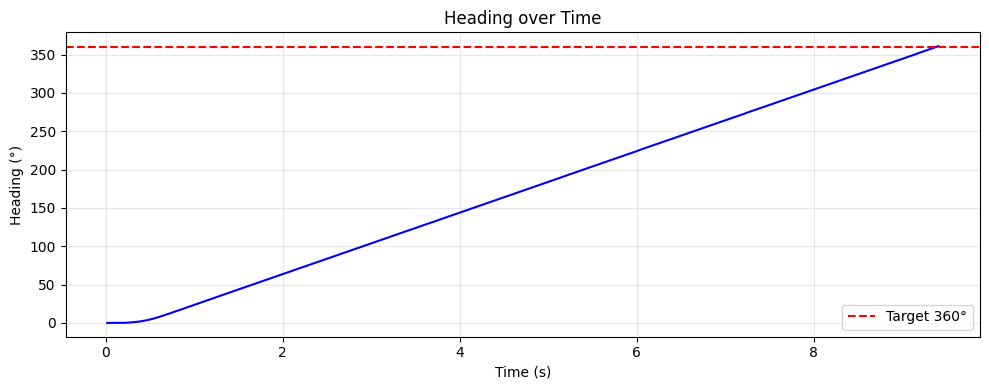

Final heading: 360.9°
Overshoot: 0.9°


In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['elapsed_s'], df['heading_deg'], color='blue')
ax.axhline(360, color='red', linestyle='--', label='Target 360°')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Heading (°)')
ax.set_title('Heading over Time')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

final_heading = df['heading_deg'].iloc[-1]
print(f'Final heading: {final_heading:.1f}°')
print(f'Overshoot: {final_heading - 360:.1f}°')

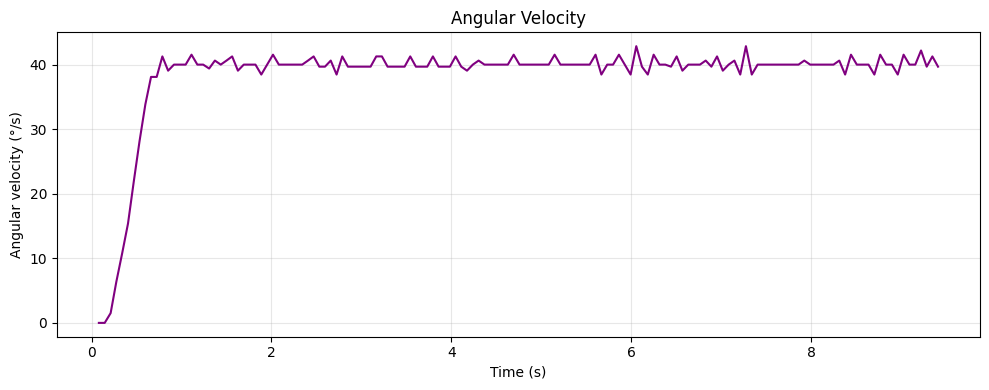

Steady-state angular vel: 40.1 ± 0.8 °/s


In [6]:
dt = df['elapsed_s'].diff()
df['angular_vel'] = df['heading_deg'].diff() / dt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['elapsed_s'], df['angular_vel'], color='purple')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Angular velocity (°/s)')
ax.set_title('Angular Velocity')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Steady-state: skip first 15 samples for ramp-up
steady = df['angular_vel'].iloc[15:]
print(f'Steady-state angular vel: {steady.mean():.1f} ± {steady.std():.1f} °/s')

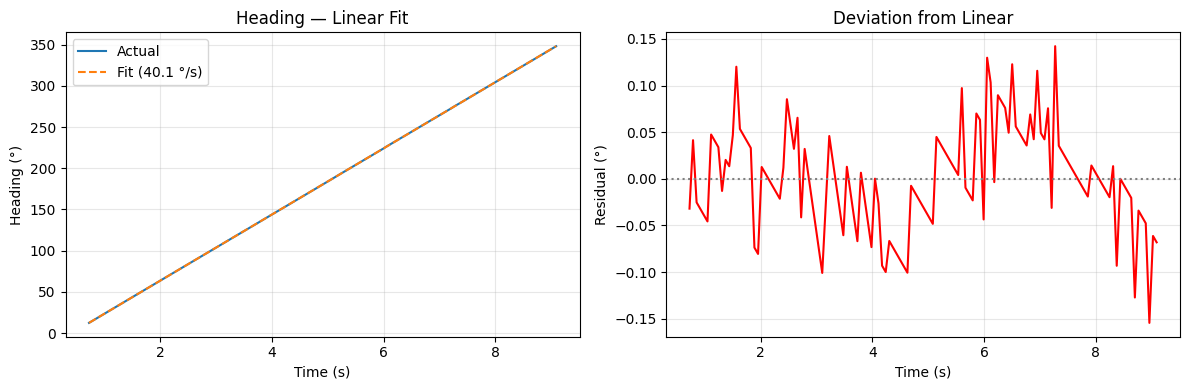

Slope: 40.1 °/s
Max residual: 0.15°
RMSE: 0.06°


In [7]:
# Use data after ramp-up (heading > 10°) and before braking (heading < 350°)
mask = (df['heading_deg'] > 10) & (df['heading_deg'] < 350)
t_fit = df.loc[mask, 'elapsed_s']
h_fit = df.loc[mask, 'heading_deg']

if len(t_fit) > 2:
    coeffs = np.polyfit(t_fit, h_fit, 1)
    h_pred = np.polyval(coeffs, t_fit)
    residuals = h_fit - h_pred

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(t_fit, h_fit, label='Actual')
    axes[0].plot(t_fit, h_pred, '--', label=f'Fit ({coeffs[0]:.1f} °/s)')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Heading (°)')
    axes[0].set_title('Heading — Linear Fit')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(t_fit, residuals, color='red')
    axes[1].axhline(0, color='gray', linestyle=':')
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Residual (°)')
    axes[1].set_title('Deviation from Linear')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f'Slope: {coeffs[0]:.1f} °/s')
    print(f'Max residual: {residuals.abs().max():.2f}°')
    print(f'RMSE: {np.sqrt((residuals**2).mean()):.2f}°')
else:
    print('Not enough steady-state data for fit')

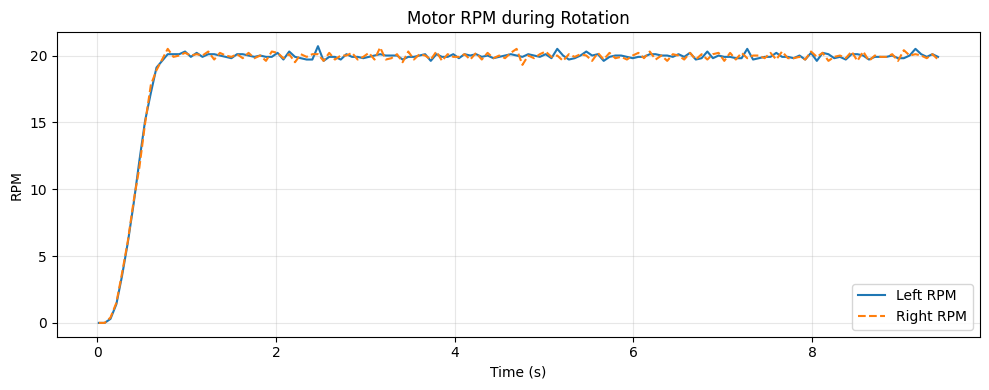

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['elapsed_s'], df['left_rpm'], label='Left RPM')
ax.plot(df['elapsed_s'], df['right_rpm'], label='Right RPM', linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('RPM')
ax.set_title('Motor RPM during Rotation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

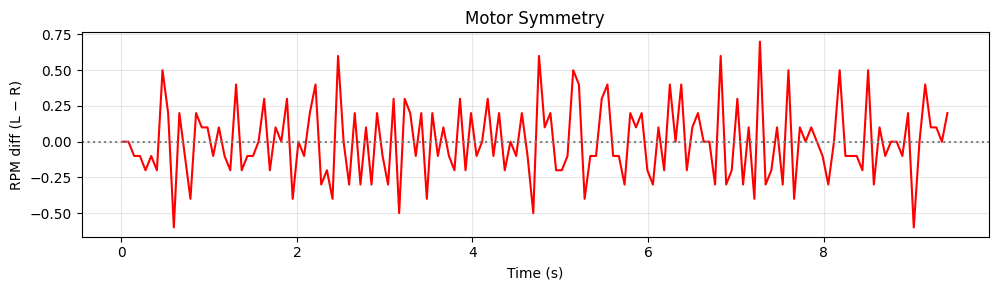

Mean RPM diff: 0.00
Std  RPM diff: 0.26


In [9]:
df['rpm_diff'] = df['left_rpm'] - df['right_rpm']

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df['elapsed_s'], df['rpm_diff'], color='red')
ax.axhline(0, color='gray', linestyle=':')
ax.set_xlabel('Time (s)')
ax.set_ylabel('RPM diff (L − R)')
ax.set_title('Motor Symmetry')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mean RPM diff: {df["rpm_diff"].mean():.2f}')
print(f'Std  RPM diff: {df["rpm_diff"].std():.2f}')

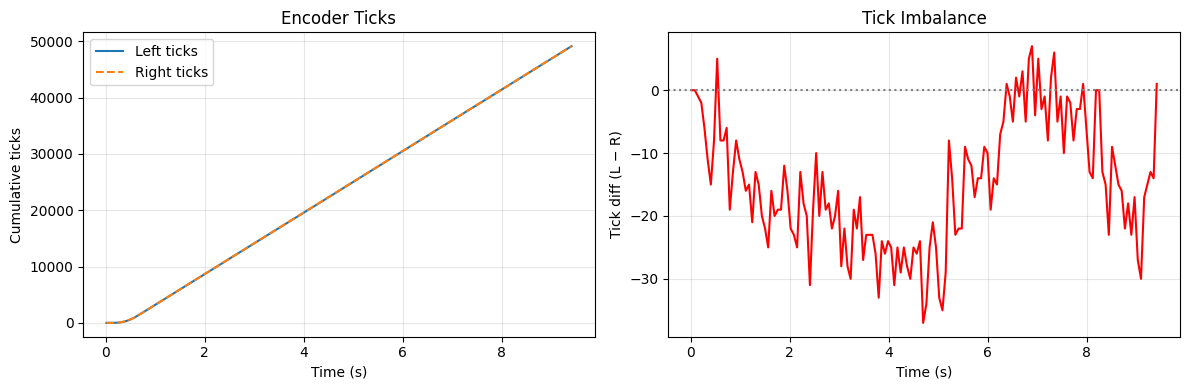

Final ticks — L: 49144  R: 49143
Tick imbalance: 1


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df['elapsed_s'], df['ticks_l'], label='Left ticks')
axes[0].plot(df['elapsed_s'], df['ticks_r'], label='Right ticks', linestyle='--')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Cumulative ticks')
axes[0].set_title('Encoder Ticks')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['elapsed_s'], df['ticks_l'] - df['ticks_r'], color='red')
axes[1].axhline(0, color='gray', linestyle=':')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Tick diff (L − R)')
axes[1].set_title('Tick Imbalance')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final ticks — L: {df["ticks_l"].iloc[-1]}  R: {df["ticks_r"].iloc[-1]}')
print(f'Tick imbalance: {df["ticks_l"].iloc[-1] - df["ticks_r"].iloc[-1]}')

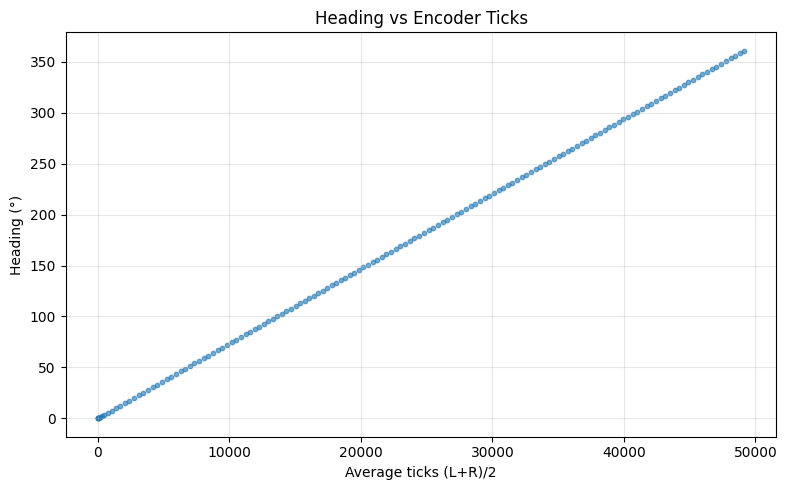

Degrees per tick: 0.0073
Ticks per full 360°: 49021


In [11]:
avg_ticks = (df['ticks_l'] + df['ticks_r']) / 2

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(avg_ticks, df['heading_deg'], s=10, alpha=0.6)
ax.set_xlabel('Average ticks (L+R)/2')
ax.set_ylabel('Heading (°)')
ax.set_title('Heading vs Encoder Ticks')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if avg_ticks.iloc[-1] > 0:
    deg_per_tick = df['heading_deg'].iloc[-1] / avg_ticks.iloc[-1]
    ticks_per_360 = 360 / deg_per_tick if deg_per_tick > 0 else float('nan')
    print(f'Degrees per tick: {deg_per_tick:.4f}')
    print(f'Ticks per full 360°: {ticks_per_360:.0f}')

In [12]:
peak_rpm = max(df['left_rpm'].max(), df['right_rpm'].max())
threshold_90 = peak_rpm * 0.9

ramp_mask = df['left_rpm'] >= threshold_90
if ramp_mask.any():
    ramp_time = df.loc[ramp_mask, 'elapsed_s'].iloc[0]
    print(f'Peak RPM: {peak_rpm:.1f}')
    print(f'Time to 90% peak: {ramp_time:.3f} s')
else:
    print('Never reached 90% of peak RPM')

Peak RPM: 20.7
Time to 90% peak: 0.661 s


In [13]:
total_time = df['elapsed_s'].iloc[-1]
final_heading = df['heading_deg'].iloc[-1]
overshoot = final_heading - 360
peak_rpm = max(df['left_rpm'].max(), df['right_rpm'].max())
avg_angular = final_heading / total_time
tick_imbalance = df['ticks_l'].iloc[-1] - df['ticks_r'].iloc[-1]

print('=== 360° Rotation Summary ===')
print(f'Duration:          {total_time:.2f} s')
print(f'Final heading:     {final_heading:.1f}°')
print(f'Overshoot:         {overshoot:+.1f}°')
print(f'Avg angular vel:   {avg_angular:.1f} °/s')
print(f'Peak motor RPM:    {peak_rpm:.1f}')
print(f'Tick imbalance:    {tick_imbalance} (L − R)')
print(f'Mean RPM diff:     {df["rpm_diff"].mean():.2f}')

=== 360° Rotation Summary ===
Duration:          9.41 s
Final heading:     360.9°
Overshoot:         +0.9°
Avg angular vel:   38.3 °/s
Peak motor RPM:    20.7
Tick imbalance:    1 (L − R)
Mean RPM diff:     0.00
